In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re 
from nltk.corpus import stopwords

In [2]:
df=pd.read_csv("IMDB_Dataset.csv")

In [3]:
df.shape

(50000, 2)

In [4]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


lowercase

In [7]:
df["review"]=df["review"].str.lower()

Remove Pumctuation

In [8]:
import string

def remove_punc(review):
    return review.translate(str.maketrans('', '', string.punctuation))
df['review'] = df['review'].apply(remove_punc)

Remove Emoji

In [9]:
def remove_emojis(review):
    return ''.join(c for c in review if c.isascii())

df['review'] = df['review'].apply(remove_emojis)

In [10]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative


In [11]:
def remove_number(review):
    return "".join(c for c in review if not c.isdigit())

df["review"]=df["review"].apply(remove_number)

In [12]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative


In [13]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mohammadakifakhtar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
stop_words = set(stopwords.words('english'))

In [15]:
def remove_stopwords(review):
    words = review.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df['review'] = df['review'].apply(remove_stopwords)

In [16]:
df

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,positive
1,wonderful little production br br filming tech...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive
...,...,...
49995,thought movie right good job wasnt creative or...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary schools n...,negative
49998,im going disagree previous comment side maltin...,negative


Stemming

In [17]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stemming(review):
    words = review.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['review'] = df['review'].apply(stemming)

In [18]:
df

,review,sentiment
0,one review mention watch oz episod youll hook ...,positive
1,wonder littl product br br film techniqu unass...,positive
2,thought wonder way spend time hot summer weeke...,positive
3,basic there famili littl boy jake think there ...,negative
4,petter mattei love time money visual stun film...,positive
...,...,...
49995,thought movi right good job wasnt creativ orig...,positive
49996,bad plot bad dialogu bad act idiot direct anno...,negative
49997,cathol taught parochi elementari school nun ta...,negative
49998,im go disagre previou comment side maltin one ...,negative


Lemmatization

In [19]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mohammadakifakhtar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [20]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

df['review'] = df['review'].apply(lemmatize)

In [21]:
df

,review,sentiment
0,one review mention watch oz episod youll hook ...,positive
1,wonder littl product br br film techniqu unass...,positive
2,thought wonder way spend time hot summer weeke...,positive
3,basic there famili littl boy jake think there ...,negative
4,petter mattei love time money visual stun film...,positive
...,...,...
49995,thought movi right good job wasnt creativ orig...,positive
49996,bad plot bad dialogu bad act idiot direct anno...,negative
49997,cathol taught parochi elementari school nun ta...,negative
49998,im go disagre previou comment side maltin one ...,negative


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

X=df["review"]
y=df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "RandomForestClassifier":RandomForestClassifier(n_estimators=200,random_state=42)
}

for name,model in models.items():
    model.fit(X_train_tfidf,y_train)
    print(name, model.score(X_test_tfidf,y_test))

Logistic Regression 0.8904
Naive Bayes 0.8624
SVM 0.8921
RandomForestClassifier 0.8577


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

X=df["review"]
y=df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

vectorizer_log = TfidfVectorizer()

X_train_tfidf = vectorizer_log.fit_transform(X_train)
X_test_tfidf = vectorizer_log.transform(X_test)

model_log=LogisticRegression(random_state=42)
model_log.fit(X_train_tfidf,y_train)

y_pred=model_log.predict(X_test_tfidf)

print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8904
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C":[0.1,1,10]
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train_tfidf,y_train)

print(grid.best_params_)

{'C': 10}


In [25]:
df_test = pd.DataFrame({
    "review": X_test_tfidf,
    "actual": y_test,
    "predicted": y_pred
})

errors = df_test[df_test["actual"] != df_test["predicted"]]
print(errors.head())

                                                  review    actual predicted
33553  <Compressed Sparse Row sparse matrix of dtype ...  positive  negative
49498  <Compressed Sparse Row sparse matrix of dtype ...  positive  negative
6113   <Compressed Sparse Row sparse matrix of dtype ...  positive  negative
15118  <Compressed Sparse Row sparse matrix of dtype ...  positive  negative
33109  <Compressed Sparse Row sparse matrix of dtype ...  positive  negative


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8904
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



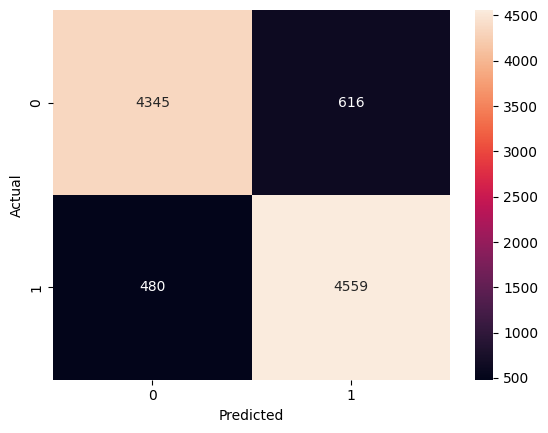

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
import pickle

pickle.dump(model_log, open("sentiment_model.pkl","wb"))
pickle.dump(vectorizer_log, open("vectorizer.pkl","wb"))